## Exercise 1: Solving the Empirical Distribution

For the empirical model, we assign a distinct parameter to each feature subgroup:
* **Parameters:** $\theta = (p_{1|00}, p_{1|01}, p_{1|10}, p_{1|11})$
* **Model:** $\hat{p}_\theta(1 | x_0, x_1) = p_{1|x_0 x_1}$

Let $S_{ij}$ be the set of $N_{ij}$ patients with features $x_0=i$ and $x_1=j$. The global negative log-likelihood decouples into independent sums for each subgroup:

$$
\ell_{ij}(p_{1|ij}) = - \sum_{n \in S_{ij}} \Big[ y_n \log(p_{1|ij}) + (1-y_n) \log(1 - p_{1|ij}) \Big]
$$

Show analytically that MLE is solved by

$$
\hat{p}_{1|ij} = \frac{1}{N_{ij}} \sum_{n \in S_{ij}} y_n
$$

### Solution

## Computational: Empirical distribution MLE for health insurance claims prediction (*)

Write python or R code to compute maximum likelihood estimates for predicting big claims based on data samples at [../notebooks/data/big-claim-events.csv](../notebooks/data/big-claim-events.csv)

Comment on the results.

### Solution

In [1]:
from pathlib import Path

import pandas as pd

In [2]:
project_root = Path('.') / '..'
notebook_dir = project_root / 'notebooks'
data_dir = notebook_dir / 'data'
big_claim_events_df = pd.read_csv(data_dir / 'big-claim-events.csv')
print('Sample values:')
big_claim_events_df.head()

Sample values:


,customer_id,year,skin_cancer,depression,big_claim
0,0,2022,0.0,0.0,1
1,1,2022,0.0,0.0,1
2,2,2022,0.0,0.0,1
3,3,2022,0.0,0.0,1
4,4,2022,0.0,0.0,1


In [3]:
big_claim_events_df.tail()

,customer_id,year,skin_cancer,depression,big_claim
2503,831,2024,0.0,0.0,1
2504,832,2024,0.0,0.0,1
2505,833,2024,1.0,0.0,0
2506,834,2024,0.0,0.0,1
2507,835,2024,1.0,0.0,1


In [4]:
# Or, using polars like the cool kids
# import polars as pl

# big_claim_events_df = pl.read_csv(data_dir / 'big-claim-events.csv')
# big_claim_events_df.head()

## Train, validation and test sets for MLE, empirical distribution (*)

Since there are no hyperparameters to choose for the empirical distribution model, we combine train and validation datasets.

Calculate the empirical MLE model for the train-validation set of records from 2022 and 2023, and compare to a test set of records from 2024.

### Solution

## Bootstrap statistics on the train-validation set for MLE, empirical distribution (**)

Use [empirical bootstrapping](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)) to estimate the mean MLE parameters and their standard deviations on the train-validation set from above.

## Set-up for exercises about health insurance customer segmentation

In [5]:
from itertools import product

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV

from data_profiling import ProfileReport

In [6]:
def target_eda(target_values: pd.Series) -> None:
    print(target_values.describe())

    # Render the boxplot in its own figure to prevent overlapping
    plt.figure()
    target_values.plot.box()
    plt.title('Boxplot')
    plt.show()

    # Create the histogram subplots with a wider figure size
    fig, axs = plt.subplots(1, 3, sharey=True, tight_layout=True, figsize=(12, 4))
    fig.suptitle('Target Distribution with Varying Bin Counts', y=1.05)

    # Loop through the axes and bin counts to plot and label them
    bin_counts = [10, 20, 50]
    for ax, bins in zip(axs, bin_counts):
        ax.hist(target_values, bins=bins)
        ax.set_title(f'Bins = {bins}')
        ax.set_xlabel('Value')

    # Add a y-axis label just to the leftmost plot
    axs[0].set_ylabel('Frequency')

    plt.show()


def make_feature_combination_array(label_mapping_values: dict) -> np.ndarray:
    res = np.array(list(product(*list(label_mapping_values.values()))))
    return res

In [7]:
customer_df = pd.read_csv(data_dir / 'simplified-customer-health.csv')
claims_df = pd.read_csv(data_dir / 'aggregate-claim-1.csv')  # use claims data post duplication error fix

X_y_raw_df = pd.merge(customer_df, claims_df, on='customer_id', how='left')
X_y_raw_df.head()

,customer_id,height,weight,occupation_group_idx,gender_idx,skin_cancer,depression,agg_claim_amount,year
0,0,162.29231,89.49357,3,1,0.0,0.0,28848.260,2022
1,0,162.29231,89.49357,3,1,0.0,0.0,24179.393,2023
2,0,162.29231,89.49357,3,1,0.0,0.0,29326.541,2024
3,1,136.25010,64.39950,0,0,0.0,0.0,34775.650,2022
4,1,136.25010,64.39950,0,0,0.0,0.0,28893.441,2023


In [8]:
X_y_raw_df.tail()

,customer_id,height,weight,occupation_group_idx,gender_idx,skin_cancer,depression,agg_claim_amount,year
2503,834,197.28094,132.118740,2,0,0.0,0.0,27792.807,2023
2504,834,197.28094,132.118740,2,0,0.0,0.0,20963.310,2024
2505,835,148.46677,72.531364,1,0,1.0,0.0,27480.486,2022
2506,835,148.46677,72.531364,1,0,1.0,0.0,35518.297,2023
2507,835,148.46677,72.531364,1,0,1.0,0.0,21220.598,2024


## Decide on train / validate / test split methodology

Using statistical and business logic considerations.

In [9]:
# Combine train / validation, as sample size small enough to justify k-fold cross validation

test_mask = X_y_raw_df['year'] == 2024

train_valid_raw_df = X_y_raw_df.loc[~test_mask, :]
test_raw_df = X_y_raw_df.loc[test_mask, :]

## Exercise: reflecting on train / validate vs test split (*)

1. What assumptions are we making with this train / test / validate split methodology?
1. What are potential weaknesses of this assumption?
1. Come up with at least one other split logic (hint: in the above )

### Solution

## Set-up: Explore target, `agg_claim_amount`

count     1672.000000
mean     22525.301824
std      11056.299227
min          1.134451
25%      15778.887750
50%      20852.002000
75%      28328.929500
max      74627.010000
Name: agg_claim_amount, dtype: float64


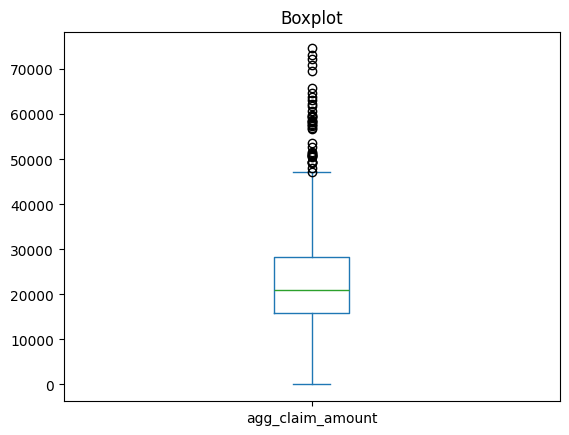

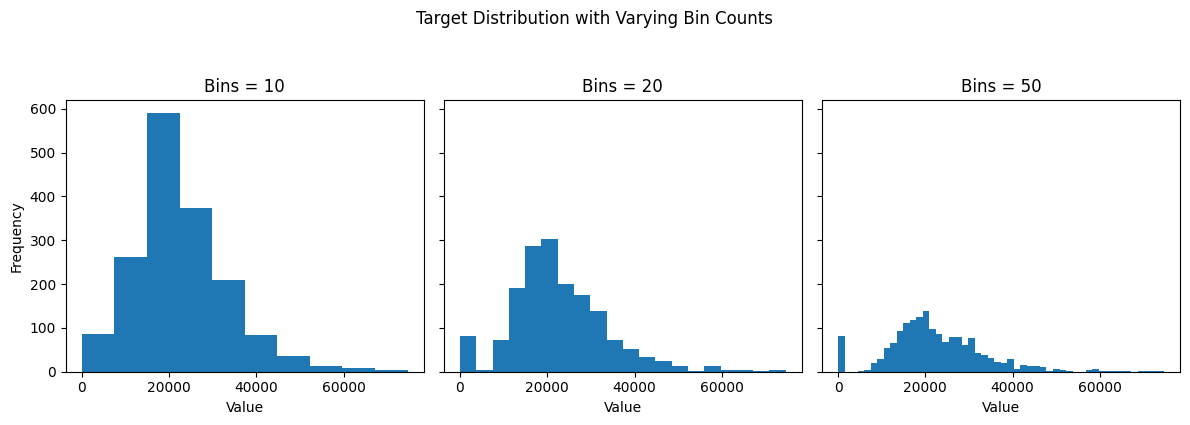

In [10]:
TARGET_COL = 'agg_claim_amount'
target_eda(train_valid_raw_df[TARGET_COL])

count    1672.000000
mean        9.687647
std         1.462450
min         0.758210
25%         9.666491
50%         9.945253
75%        10.251674
max        11.220271
Name: agg_claim_amount, dtype: float64


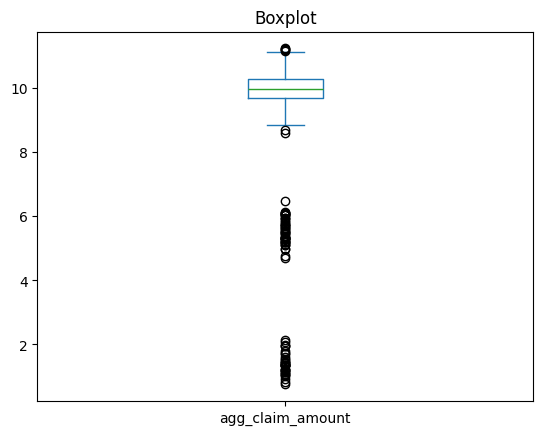

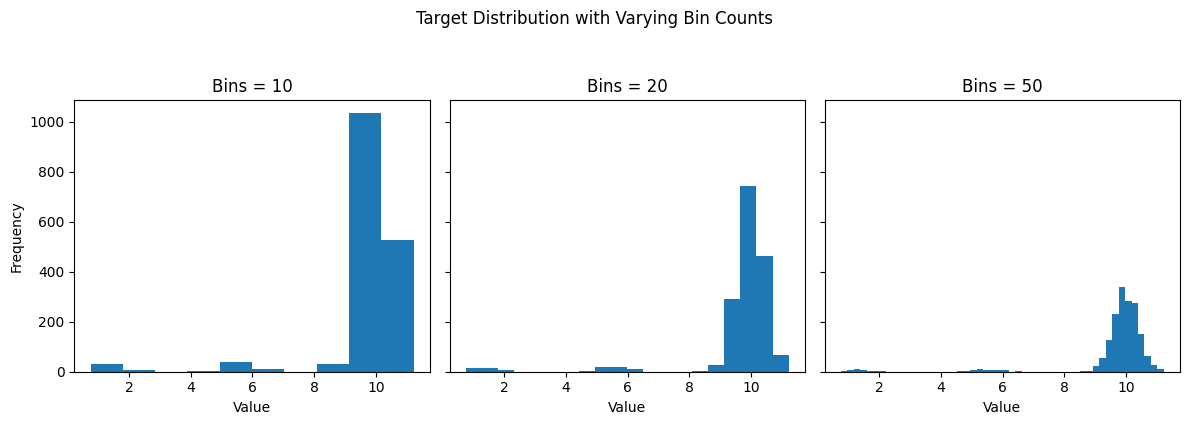

In [11]:
# Consider log-transformed data
y_train_transformed = np.log(train_valid_raw_df[TARGET_COL] + 1)

target_eda(y_train_transformed)

## Exercise: train / validation / test split methodology (*)

What are reasons for and against splitting data into train / validation / tests before doing feature selection and engineering?

### Solution

## Set-up: Grouping the target for segment predictions

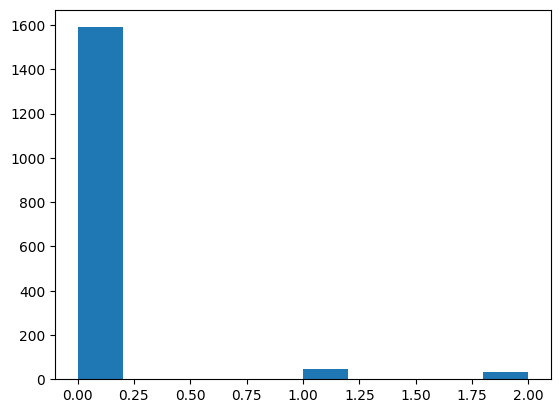

In [12]:
target_classifier = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(y_train_transformed.to_frame())
target_train = target_classifier.predict(y_train_transformed.to_frame())
plt.hist(target_train);

### Calculate claims statistics on each class

to satisfy studying effects on sub-populations

In [13]:
claim_class_df = pd.DataFrame(dict(
    log_agg_claim_amount=y_train_transformed,
    predicted_class=target_train
)).groupby('predicted_class')
for class_label, class_df in claim_class_df:
    print(f'Statistics for class group {class_label}:')
    print(class_df['log_agg_claim_amount'].describe())

Statistics for class group 0:
count    1590.000000
mean        9.989793
std         0.405698
min         8.587946
25%         9.719467
50%         9.977813
75%        10.266268
max        11.220271
Name: log_agg_claim_amount, dtype: float64
Statistics for class group 1:
count    48.000000
mean      5.545300
std       0.398151
min       4.706208
25%       5.264311
50%       5.506459
75%       5.869183
max       6.469675
Name: log_agg_claim_amount, dtype: float64
Statistics for class group 2:
count    34.000000
mean      1.405909
std       0.353706
min       0.758210
25%       1.161463
50%       1.369118
75%       1.605514
max       2.136898
Name: log_agg_claim_amount, dtype: float64


**Note** that the label values seem to increase as log-claims decrease (so class assignment seems order reversing)

## Set-up: Process data for classification

In [14]:
# Define feature types based on your specifications
numerical_features = ['height', 'weight']
categorical_features = ['occupation_group_idx']  # 4 categories [0,1,2,3]
binary_features = ['gender_idx', 'skin_cancer', 'depression']  # Binary variables
feature_columns = numerical_features + categorical_features + binary_features

# Create ColumnTransformer
feature_preprocessor = ColumnTransformer(
    transformers=[
        # Scale numerical features (height, weight)
        ('num', StandardScaler(), numerical_features),
        
        # One-hot encode occupation_group_idx (4 categories)
        # Using drop='first' to avoid multicollinearity
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        
        # Keep binary features as-is (they're already 0/1)
        # Using 'passthrough' to keep them unchanged
        ('bin', 'passthrough', binary_features)
    ])

## Set-up: Fit logistic regression

Use default number of cross-validation splits $k=5$.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score

# Compare models via CV on train+validation only

# Model A: Logistic Regression (already has built-in CV)
lr_pipeline = Pipeline([
    ('preprocessor', feature_preprocessor),
    ('classifier', LogisticRegressionCV(random_state=42, max_iter=1000, scoring='balanced_accuracy'))
])
lr_cv_scores = cross_val_score(
    lr_pipeline, train_valid_raw_df[feature_columns], target_train,
    cv=5, scoring='balanced_accuracy'
)
# Fit the lr_pipeline on the full train+validation set
lr_pipeline.fit(train_valid_raw_df[feature_columns], target_train)

/Users/paullarsen/work/projects/risk-ai-workshop/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/paullarsen/work/projects/risk-ai-workshop/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

### Inspect chosen hyperparameter

$C$ in sklearn is the inverse regulatrization strength.

In [16]:
pd.Series(lr_pipeline['classifier'].C_)

0    21.544347
1    21.544347
2    21.544347
dtype: float64

## Inspect fitted parameters with above hyperparameters on entire train + validation set

In [17]:
pd.DataFrame(lr_pipeline['classifier'].coef_)

,0,1,2,3,4,5,6,7
0,-3.959915,4.164255,-0.156593,0.773363,-0.313290,1.083021,3.260663,3.411198
1,2.281406,-2.528770,0.114006,2.420913,0.154907,2.972899,-1.877379,-1.832174
2,1.678509,-1.635486,0.042587,-3.194276,0.158383,-4.055921,-1.383284,-1.579024


## Set-up: Fit decision trees

In [18]:
# Model: Decision Tree with hyperparameter tuning
dt_pipeline = Pipeline([
    ('preprocessor', feature_preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
param_grid = {
    'classifier__max_depth': [2, 3, 5, 7, 10, None],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
}
dt_grid = GridSearchCV(
    dt_pipeline, param_grid,
    cv=5, scoring='balanced_accuracy', n_jobs=-1
)
dt_grid.fit(train_valid_raw_df[feature_columns], target_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

## Exercise: Evaluate fitted logistic regression cluster-assignment on sub-population categories (**)

This task is complicated by the presence of categorial and numerical features. For categorical features, we just take the (Cartesian) product of all possible values, and evaluate the model on those values.

With numerical features in the mix, we need to use some statistics.

### Solution

## Wrapping-up: Model selection based on train + validation data split

In [19]:
print("=== Model Selection (CV on train+validation) ===")
print(f"Logistic Regression - mean balanced accuracy: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")
print(f"Decision Tree       - mean balanced accuracy: {dt_grid.best_score_:.4f}")
print(f"  Best DT params: {dt_grid.best_params_}")

# Select model
if lr_cv_scores.mean() >= dt_grid.best_score_:
    print("\n>>> Selected model: Logistic Regression")
    final_pipeline = lr_pipeline
    final_pipeline.fit(train_valid_raw_df[feature_columns], target_train)
else:
    print("\n>>> Selected model: Decision Tree")
    final_pipeline = dt_grid.best_estimator_  # already refit on full train+validation

=== Model Selection (CV on train+validation) ===
Logistic Regression - mean balanced accuracy: 0.4787 (+/- 0.1167)
Decision Tree       - mean balanced accuracy: 0.4921
  Best DT params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5}

>>> Selected model: Decision Tree


## Finally: estimate generalization error on holdout test set

In [20]:
y_test_transformed = np.log(test_raw_df[TARGET_COL] + 1)
target_test = target_classifier.predict(y_test_transformed.to_frame())

y_test_pred = final_pipeline.predict(test_raw_df.loc[:, feature_columns])

print("\n=== Generalization Error Estimate (holdout test set) ===")
print(f"Accuracy:          {accuracy_score(target_test, y_test_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(target_test, y_test_pred):.4f}")
print()
print(classification_report(target_test, y_test_pred))


=== Generalization Error Estimate (holdout test set) ===
Accuracy:          0.9785
Balanced accuracy: 0.7369

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       795
           1       0.88      0.62      0.73        24
           2       0.83      0.59      0.69        17

    accuracy                           0.98       836
   macro avg       0.90      0.74      0.80       836
weighted avg       0.98      0.98      0.98       836



## Reflections on model transparency
The $\beta_0$ coefficients of fitted logistic regression, one value for each of our 3 clusters:

In [21]:
pd.Series(lr_pipeline['classifier'].intercept_)

0    2.972705
1   -2.772579
2   -0.200127
dtype: float64

And the remaining 8 x 3 $\beta$ parameters:

In [22]:
pd.DataFrame(lr_pipeline['classifier'].coef_)

,0,1,2,3,4,5,6,7
0,-3.959915,4.164255,-0.156593,0.773363,-0.313290,1.083021,3.260663,3.411198
1,2.281406,-2.528770,0.114006,2.420913,0.154907,2.972899,-1.877379,-1.832174
2,1.678509,-1.635486,0.042587,-3.194276,0.158383,-4.055921,-1.383284,-1.579024
